In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

import matplotlib.pyplot as plt

In [16]:
from pathlib import Path
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

In [17]:
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

RESULTS_DIR = PROJECT_ROOT / "models" / "results"
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

In [18]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [19]:
val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [20]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset = ImageFolder(TEST_DIR, transform=val_test_transform)

In [21]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [23]:
model = models.mobilenet_v2(pretrained=True)

In [24]:
for param in model.features.parameters():
    param.requires_grad = False

In [25]:
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 2)
)

model = model.to(device)

In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)

In [ ]:
EPOCHS = 20
best_acc = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_epoch = 0

In [28]:
for epoch in range(EPOCHS):

    # ---------------- TRAINING ----------------
    model.train()

    running_loss = 0.0

    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # accuracy tracking
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---------------- Validation ----------------
    model.eval()

    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch + 1

        model_path = MODEL_DIR / "mobilenetv2_best.pth"

        torch.save(model.state_dict(), model_path)

        print("✅ Best model saved!")


Epoch [1/20]
Train Loss: 0.6042 | Train Acc: 0.7100
Val Loss: 0.4961 | Val Acc: 0.9100
✅ Best model saved!

Epoch [2/20]
Train Loss: 0.4731 | Train Acc: 0.8721
Val Loss: 0.3831 | Val Acc: 0.9600
✅ Best model saved!

Epoch [3/20]
Train Loss: 0.3880 | Train Acc: 0.9293
Val Loss: 0.3058 | Val Acc: 0.9800
✅ Best model saved!

Epoch [4/20]
Train Loss: 0.3348 | Train Acc: 0.9521
Val Loss: 0.2534 | Val Acc: 0.9833
✅ Best model saved!

Epoch [5/20]
Train Loss: 0.2806 | Train Acc: 0.9600
Val Loss: 0.2185 | Val Acc: 0.9833

Epoch [6/20]
Train Loss: 0.2554 | Train Acc: 0.9679
Val Loss: 0.1894 | Val Acc: 0.9900
✅ Best model saved!

Epoch [7/20]
Train Loss: 0.2277 | Train Acc: 0.9700
Val Loss: 0.1723 | Val Acc: 0.9867

Epoch [8/20]
Train Loss: 0.2058 | Train Acc: 0.9721
Val Loss: 0.1529 | Val Acc: 0.9800

Epoch [9/20]
Train Loss: 0.1950 | Train Acc: 0.9686
Val Loss: 0.1371 | Val Acc: 0.9933
✅ Best model saved!

Epoch [10/20]
Train Loss: 0.1934 | Train Acc: 0.9679
Val Loss: 0.1260 | Val Acc: 0.9933

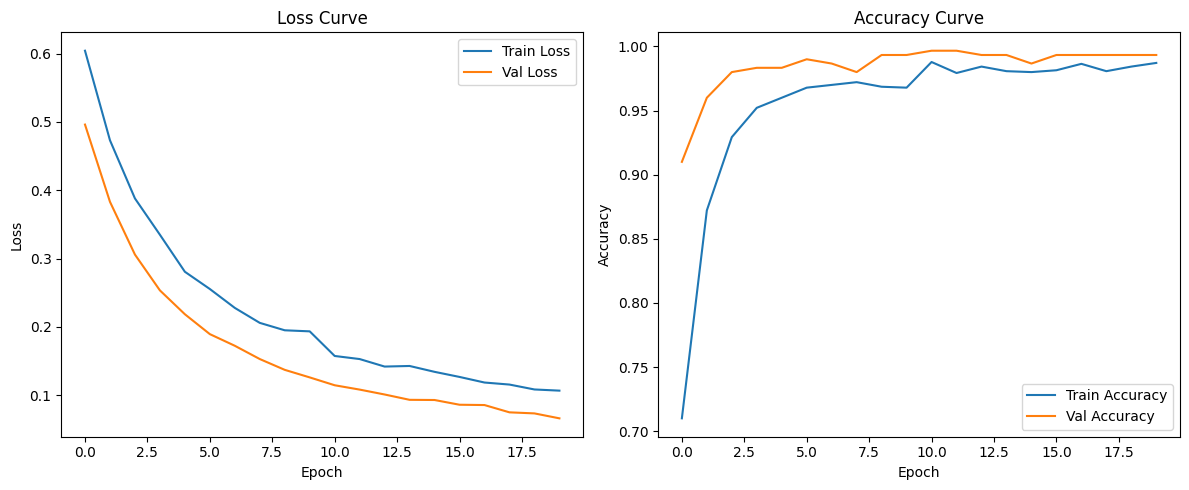

In [29]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()

plt.savefig(RESULTS_DIR / "loss_acc.png")
plt.show()